In [ ]:
топчик

In [1]:
import pandas as pd

In [3]:
dt = pd.read_csv('test_d.csv')
print(dt['1. Существенное'].value_counts())
print(dt['1. Направление'].value_counts())
dt = dt.fillna(0)


1. Существенное
0    842
1    158
Name: count, dtype: int64
1. Направление
 1.0    138
-1.0     17
Name: count, dtype: int64


In [ ]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загружаем данные
data = dt
X = dt['filtered_text']  # Признаки
y = dt['1. Направление']  # Метки классов


vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_tfidf = vectorizer.fit_transform(X)
# Разбиваем на тренировочную и тестовую выборки (80% на обучение, 20% на тест)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.15, random_state=42)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Определение диапазонов значений для случайного поиска
param_dist = {
   'n_estimators': randint(50, 200),
   'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_leaf': [1, 2, 4]
}

# Создание модели и настройка с использованием случайного поиска
rf_model = RandomForestClassifier()
#n_estimators=179, max_depth=40, min_samples_leaf=2, random_state=42
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=100, cv=5)
random_search.fit(X_train, y_train)

# Вывод наилучших гиперпараметров и оценки
print("Best Hyperparameters:", random_search.best_params_)
print("Best Cross-Validation Score:", random_search.best_score_)

# Делаем предсказания
y_pred = random_search.predict(X_test)

# Оцениваем точность
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 82}
Best Cross-Validation Score: 0.9035294117647059
Accuracy: 0.94


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_true = y_test, y_pred = y_pred))

              precision    recall  f1-score   support

        -1.0       1.00      0.25      0.40         4
         0.0       0.95      0.98      0.97       129
         1.0       0.87      0.76      0.81        17

    accuracy                           0.94       150
   macro avg       0.94      0.67      0.73       150
weighted avg       0.94      0.94      0.93       150



In [ ]:
print(confusion_matrix(y_true = y_test, y_pred = y_pred))

[[  1   3   0]
 [  0 127   2]
 [  0   4  13]]


In [ ]:
#можно построить две бинарных модели по разным выборкам и объединить на циклом

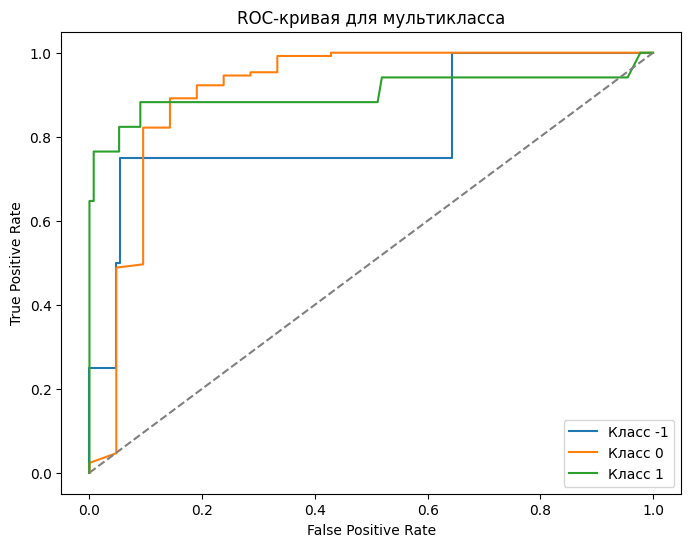

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Бинаризуем метки классов
y_test_bin = label_binarize(y_test, classes=[-1, 0, 1])  # Если классы [0,1,2]

# Предсказанные вероятности
y_probs = random_search.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i in range(y_test_bin.shape[1]):  # Для каждого класса
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'Класс {i-1}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Линия случайных предсказаний
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для мультикласса')
plt.legend()
plt.show()

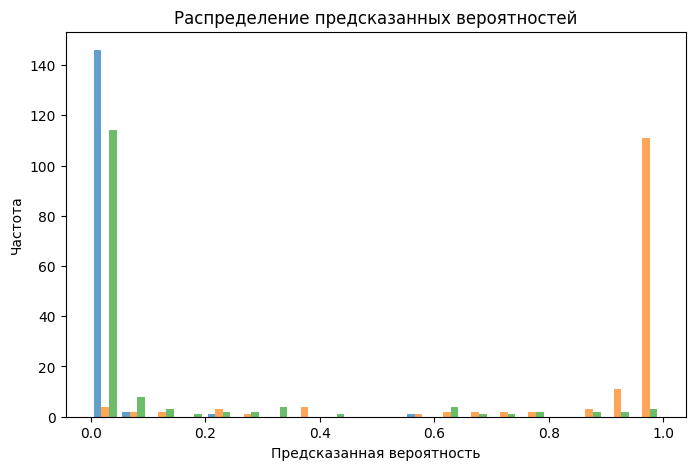

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_probs, bins=20, alpha=0.7)
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Частота')
plt.title('Распределение предсказанных вероятностей')
plt.show()

In [ ]:
!pip install imbalanced-learn

In [6]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import make_classification
from sklearn.feature_extraction.text import TfidfVectorizer


data = dt
X = dt['filtered_text']  # Признаки
y = dt['1. Направление']
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X = vectorizer.fit_transform(X)  # Метки классов



# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Первая задача: 0 vs {1, -1}
y_train_bin1 = (y_train != 0).astype(int)  # 0 остаётся 0, {1, -1} превращаются в 1
y_test_bin1 = (y_test != 0).astype(int)

# Балансируем с помощью SMOTE (oversampling)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train_bin1)

# Обучаем первую модель
clf1 = RandomForestClassifier(class_weight='balanced', random_state=42)
clf1.fit(X_train_bal, y_train_bal)

# Предсказания
y_pred_bin1 = clf1.predict(X_test)

# Оцениваем первую модель
print("Первая модель (0 vs {1, -1}):")
print(classification_report(y_test_bin1, y_pred_bin1))

# 2. Вторая классификация: 1 vs -1 (только среди не-нулевых)

#X_train_bin2 = np.where(X_train, )

X_train_bin2 = X_train[y_train_bin1 == 1]
y_train_bin2 = y_train[y_train_bin1 == 1]  # Берём оригинальные метки 1 и -1

X_test_bin2 = X_test[y_pred_bin1 == 1]  # Берём тестовые предсказания, где не 0
y_test_bin2 = y_test[y_pred_bin1 == 1]  # Истинные метки

# Балансируем классы снова
X_train_bal2, y_train_bal2 = smote.fit_resample(X_train_bin2, y_train_bin2)

clf2 = RandomForestClassifier(class_weight='balanced', random_state=42)
clf2.fit(X_train_bal2, y_train_bal2)

# Предсказания для 1 vs -1
y_pred_bin2 = clf2.predict(X_test_bin2)

# Оценка второй модели
print("Вторая модель (1 vs -1):")
print(classification_report(y_test_bin2, y_pred_bin2))

Первая модель (0 vs {1, -1}):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       171
           1       0.83      0.69      0.75        29

    accuracy                           0.94       200
   macro avg       0.89      0.83      0.86       200
weighted avg       0.93      0.94      0.93       200

Вторая модель (1 vs -1):
              precision    recall  f1-score   support

        -1.0       1.00      0.50      0.67         2
         0.0       0.00      0.00      0.00         4
         1.0       0.78      1.00      0.88        18

    accuracy                           0.79        24
   macro avg       0.59      0.50      0.51        24
weighted avg       0.67      0.79      0.71        24



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Загрузка данных
data = dt
X = dt['filtered_text']  # Признаки
y = dt['1. Направление']  # Метки классов

# Преобразование текста в числовые признаки
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X = vectorizer.fit_transform(X)

# Подготовка меток для двух моделей
# Первая модель: 0 vs 1
y_0_vs_1 = np.where(y == 1, 1, 0)  # 1 -> 1, остальное -> 0

# Вторая модель: 0 vs -1
y_0_vs_minus1 = np.where(y == -1, 1, 0)  # -1 -> 1, остальное -> 0

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train_0_vs_1, y_test_0_vs_1 = train_test_split(
    X, y_0_vs_1, test_size=0.2, random_state=42
)
_, _, y_train_0_vs_minus1, y_test_0_vs_minus1 = train_test_split(
    X, y_0_vs_minus1, test_size=0.2, random_state=42
)

# Балансировка классов с помощью SMOTE
smote = SMOTE(random_state=42)

# Балансировка для первой модели
X_train_0_vs_1_bal, y_train_0_vs_1_bal = smote.fit_resample(X_train, y_train_0_vs_1)

# Балансировка для второй модели
X_train_0_vs_minus1_bal, y_train_0_vs_minus1_bal = smote.fit_resample(X_train, y_train_0_vs_minus1)

# Обучение моделей
# Первая модель: 0 vs 1
clf_0_vs_1 = RandomForestClassifier(class_weight='balanced', random_state=42)
clf_0_vs_1.fit(X_train_0_vs_1_bal, y_train_0_vs_1_bal)

# Вторая модель: 0 vs -1
clf_0_vs_minus1 = RandomForestClassifier(class_weight='balanced', random_state=42)
clf_0_vs_minus1.fit(X_train_0_vs_minus1_bal, y_train_0_vs_minus1_bal)

# Предсказания
# Предсказания для первой модели
y_pred_0_vs_1 = clf_0_vs_1.predict(X_test)

# Предсказания для второй модели
y_pred_0_vs_minus1 = clf_0_vs_minus1.predict(X_test)

# Голосование для итоговых предсказаний
final_predictions = []
for pred_0_vs_1, pred_0_vs_minus1 in zip(y_pred_0_vs_1, y_pred_0_vs_minus1):
    if pred_0_vs_1 == 1 and pred_0_vs_minus1 == 0:
        final_predictions.append(1)  # Класс 1
    elif pred_0_vs_1 == 0 and pred_0_vs_minus1 == 1:
        final_predictions.append(-1)  # Класс -1
    else:
        final_predictions.append(0)  # Класс 0

# Истинные метки для тестовых данных
y_test = np.where(y_test_0_vs_1 == 1, 1, np.where(y_test_0_vs_minus1 == 1, -1, 0))

# Отчет о классификации
print("Итоговый отчет:")
print(classification_report(y_test, final_predictions, target_names=['-1', '0', '1']))

NameError: name 'dt' is not defined

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay

# Загрузка данных
data = dt
X = dt['filtered_text']  # Признаки
y = dt['1. Направление']  # Метки классов

# Преобразование текста в числовые признаки
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X = vectorizer.fit_transform(X)

# Подготовка меток для двух моделей
# Первая модель: 0 vs 1
y_0_vs_1 = np.where(y == 1, 1, 0)  # 1 -> 1, остальное -> 0

# Вторая модель: 0 vs -1
y_0_vs_minus1 = np.where(y == -1, 1, 0)  # -1 -> 1, остальное -> 0

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train_0_vs_1, y_test_0_vs_1 = train_test_split(
    X, y_0_vs_1, test_size=0.2, random_state=42
)
_, _, y_train_0_vs_minus1, y_test_0_vs_minus1 = train_test_split(
    X, y_0_vs_minus1, test_size=0.2, random_state=42
)

# Балансировка классов с помощью SMOTE
smote = SMOTE(random_state=42)

# Балансировка для первой модели
X_train_0_vs_1_bal, y_train_0_vs_1_bal = smote.fit_resample(X_train, y_train_0_vs_1)

# Балансировка для второй модели
X_train_0_vs_minus1_bal, y_train_0_vs_minus1_bal = smote.fit_resample(X_train, y_train_0_vs_minus1)

# Обучение моделей
# Первая модель: 0 vs 1
from sklearn.naive_bayes import MultinomialNB
nb_0_vs_1 = MultinomialNB()
nb_0_vs_1.fit(X_train_0_vs_1_bal, y_train_0_vs_1_bal)

# Вторая модель: 0 vs -1
nb_0_vs_minus1 = MultinomialNB()
nb_0_vs_minus1.fit(X_train_0_vs_minus1_bal, y_train_0_vs_minus1_bal)

# Предсказания
# Предсказания для первой модели
y_pred_0_vs_1 = nb_0_vs_1.predict(X_test)

# Предсказания для второй модели
y_pred_0_vs_minus1 = nb_0_vs_minus1.predict(X_test)

# Голосование для итоговых предсказаний
final_predictions = []
for pred_0_vs_1, pred_0_vs_minus1 in zip(y_pred_0_vs_1, y_pred_0_vs_minus1):
    if pred_0_vs_1 == 1 and pred_0_vs_minus1 == 0:
        final_predictions.append(1)  # Класс 1
    elif pred_0_vs_1 == 0 and pred_0_vs_minus1 == 1:
        final_predictions.append(-1)  # Класс -1
    else:
        final_predictions.append(0)  # Класс 0

# Истинные метки для тестовых данных
y_test = np.where(y_test_0_vs_1 == 1, 1, np.where(y_test_0_vs_minus1 == 1, -1, 0))

# Отчет о классификации
print("Итоговый отчет:")
print(classification_report(y_test, final_predictions, target_names=['-1', '0', '1']))

Итоговый отчет:
              precision    recall  f1-score   support

          -1       0.04      0.25      0.06         4
           0       0.95      0.71      0.81       171
           1       0.36      0.64      0.46        25

    accuracy                           0.69       200
   macro avg       0.45      0.53      0.44       200
weighted avg       0.85      0.69      0.75       200

